## **Analisis Prediksi Permintaan Listrik Harian dengan Skforecast dan LightGBM**

## Pendahuluan

Notebook ini bertujuan untuk melakukan prediksi permintaan listrik harian menggunakan metode forecasting berbasis machine learning. Model yang digunakan adalah LightGBM yang diintegrasikan dengan Skforecast melalui ForecasterRecursive. Selain menghasilkan prediksi, penelitian ini juga menerapkan Explainable Artificial Intelligence (XAI) menggunakan SHAP (SHapley Additive exPlanations) sehingga faktor-faktor yang mempengaruhi hasil prediksi dapat diketahui dan diinterpretasikan.

## Instalasi Library

Dibawah ini digunakan untuk menginstal library yang diperlukan dalam analisis. Library Skforecast digunakan untuk forecasting time series, LightGBM digunakan sebagai algoritma machine learning, sedangkan SHAP digunakan untuk menjelaskan hasil prediksi model.

In [14]:
!pip install skforecast lightgbm shap

## Import Library

Dibawah ini mengimpor seluruh library yang dibutuhkan selama proses analisis.

Fungsi masing-masing library:

* pandas : manipulasi data
* matplotlib : visualisasi data
* shap : interpretasi model
* permutation_importance : mengukur pentingnya fitur
* PartialDependenceDisplay : membuat partial dependence plot
* LGBMRegressor : algoritma LightGBM
* fetch_dataset : mengambil dataset contoh
* ForecasterRecursive : model forecasting time series

In [15]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Mengambil Dataset

Dibawah ini untuk dataset yang digunakan adalah dataset VIC Electricity yang berisi informasi konsumsi listrik dan temperatur pada wilayah Victoria, Australia.

Output dari code di bawah ini menampilkan beberapa baris pertama dataset untuk memahami struktur data yang digunakan.

In [16]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


## Agregasi Data Harian

Code dibawah ini data asli memiliki frekuensi waktu yang lebih kecil dari harian. Oleh karena itu dilakukan resampling menjadi data harian.

Proses yang dilakukan:

* Demand dijumlahkan setiap hari.
* Temperature dihitung rata-ratanya setiap hari.

Tujuan langkah ini adalah mengubah data menjadi time series harian sehingga lebih mudah digunakan untuk forecasting.

In [17]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


## Pembagian Data Training dan Testing

Data dibagi menjadi:

* Data Training → digunakan untuk melatih model.
* Data Testing → digunakan untuk menguji kemampuan model melakukan prediksi.

Pemisahan ini penting agar evaluasi model dilakukan pada data yang belum pernah dilihat sebelumnya.

In [18]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

## Instalasi Ulang Library

Ini memastikan versi library yang digunakan sesuai dengan tutorial sehingga tidak terjadi error kompatibilitas.

In [19]:
!pip install -q skforecast==0.15.1 lightgbm shap

## Import Library Ulang

Melakukan import ulang library setelah instalasi selesai dilakukan.

Tujuannya memastikan seluruh modul telah dimuat ke dalam environment notebook.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Verifikasi Library

Digunakan untuk memeriksa:

* versi Skforecast yang digunakan
* keberadaan class ForecasterRecursive

Hal ini memastikan library berhasil terinstal dengan benar.

In [25]:
import skforecast
print(skforecast.__version__)
print(ForecasterRecursive)

0.22.0
<class 'skforecast.recursive._forecaster_recursive.ForecasterRecursive'>


## Membuat Model Forecasting

Code di bawah ini membangun model forecasting.

Komponen model:

* LightGBM sebagai algoritma regresi.
* lags=7 berarti model menggunakan data 7 hari sebelumnya untuk memprediksi hari berikutnya.

Artinya model mempelajari pola historis selama satu minggu terakhir.

In [26]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
from skforecast.recursive import ForecasterRecursive
from lightgbm import LGBMRegressor

forecaster = ForecasterRecursive(
    estimator=LGBMRegressor(random_state=123, verbose=-1),
    lags=7
)

forecaster.fit(
    y=data_train['Demand'],
    exog=data_train[['Temperature']]
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 03:58:54 
Last fit date: 2026-06-11 03:58:54 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

## Feature Importance

Digunakan untuk mengetahui fitur mana yang paling berpengaruh terhadap hasil prediksi.

Semakin tinggi nilai importance maka semakin besar kontribusi fitur tersebut terhadap model.

In [27]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## Membentuk Data Training

Data time series diubah menjadi bentuk supervised learning.

Input (X):

* lag_1
* lag_2
* lag_3
* lag_4
* lag_5
* lag_6
* lag_7
* Temperature

Output (y):

* Demand

Tahap ini sangat penting karena algoritma machine learning memerlukan format input-output.

In [28]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


## Membuat SHAP Explainer

SHAP Explainer digunakan untuk menjelaskan kontribusi masing-masing fitur terhadap hasil prediksi model.

SHAP bekerja berdasarkan konsep Shapley Value dari teori permainan.

In [30]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

## SHAP Bar Plot

Visualisasi ini menunjukkan tingkat kepentingan fitur secara keseluruhan.

Fitur dengan batang paling panjang merupakan fitur yang paling berpengaruh terhadap prediksi.

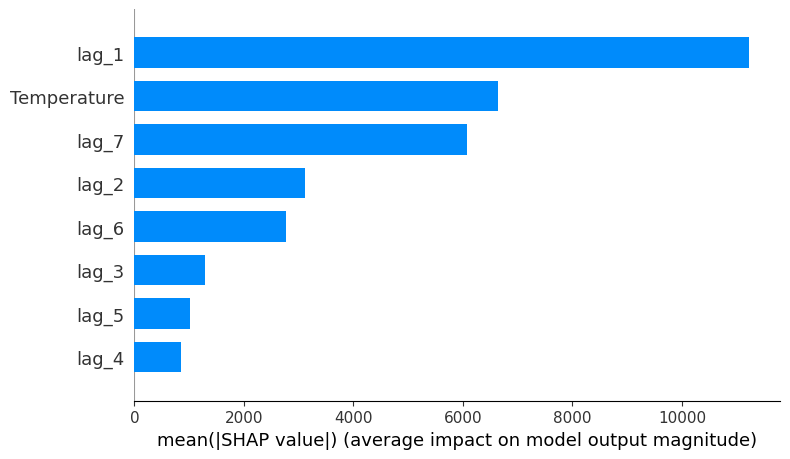

In [31]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

## SHAP Summary Plot

Visualisasi ini memperlihatkan:

* pentingnya fitur
* arah pengaruh fitur
* distribusi kontribusi fitur

Warna merah menunjukkan nilai fitur tinggi, sedangkan biru menunjukkan nilai fitur rendah.

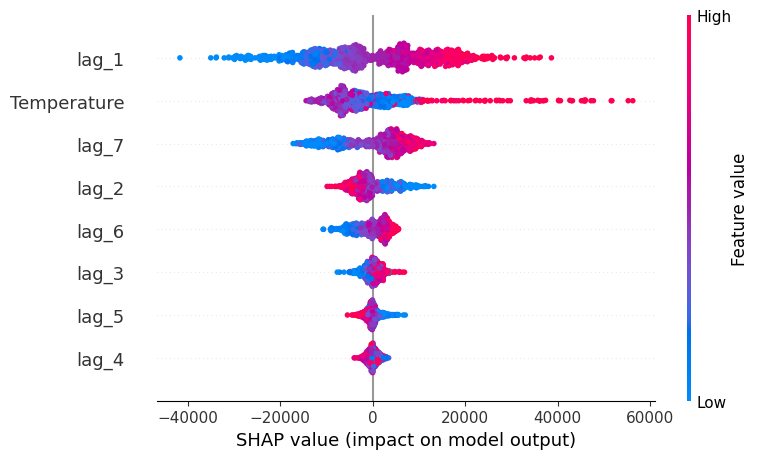

In [32]:
shap.summary_plot(shap_values, X_train)

## Inisialisasi Javascript SHAP

Digunakan untuk mengaktifkan visualisasi interaktif SHAP pada notebook.

In [33]:
shap.initjs()

## SHAP Force Plot Observasi Pertama

Menjelaskan secara detail alasan model menghasilkan prediksi tertentu pada observasi pertama.

Terlihat fitur mana yang:
* menaikkan prediksi
* menurunkan prediksi

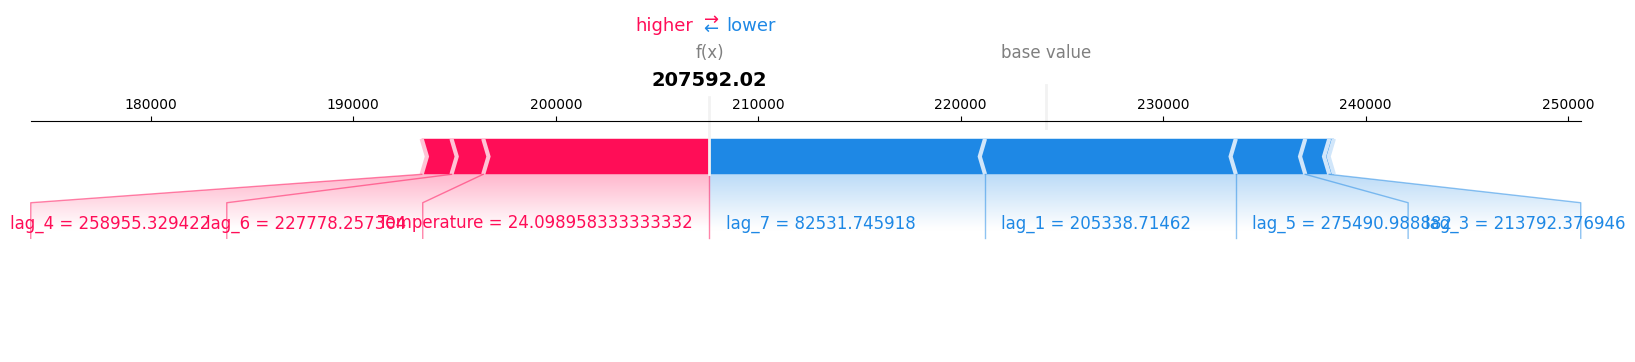

In [34]:
# Force plot for the first observation
# ==============================================================================
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_train.iloc[0],
    matplotlib=True
)

## SHAP Force Plot 200 Observasi

Visualisasi ini memperlihatkan kontribusi fitur pada 200 observasi sekaligus.

Tujuannya untuk memahami pola pengaruh fitur pada banyak data secara bersamaan.

In [35]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
from IPython.display import HTML

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

shap.save_html("force_plot_200.html", force_plot)

with open("force_plot_200.html", "r", encoding="utf-8") as f:
    html = f.read()

html = html.replace(
    "<body>",
    """
    <body style="background-color:white;">
    <style>
        body {
            background-color:white !important;
            color:black !important;
        }
    </style>
    """
)

HTML(html)

## SHAP Dependence Plot

Menganalisis hubungan antara Temperature dan hasil prediksi.

Grafik ini menunjukkan bagaimana perubahan suhu memengaruhi permintaan listrik.


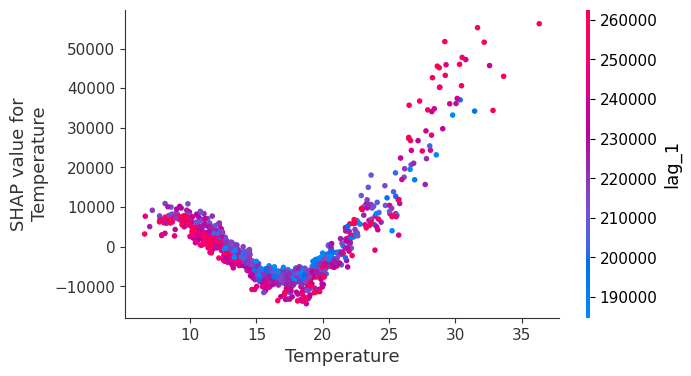

In [36]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

## Melakukan Prediksi

Model digunakan untuk memprediksi permintaan listrik pada periode mendatang menggunakan data testing.

Output berupa nilai prediksi kebutuhan listrik.

In [37]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


## Membentuk Matriks Prediksi

Menampilkan data input yang digunakan model saat melakukan prediksi.

Isi matriks:

* lag_1 sampai lag_7
* Temperature

In [38]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


## Force Plot untuk Prediksi Tertentu

Menganalisis satu hasil prediksi spesifik, yaitu tanggal:

2014-12-22

Tujuannya mengetahui faktor yang menyebabkan model menghasilkan nilai prediksi tersebut.

In [39]:
# Force plot for a specific prediction
# ==============================================================================
from IPython.display import HTML
import shap

# Force plot for a specific prediction
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)

shap_values = explainer.shap_values(X_predict)

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

shap.save_html("force_plot_specific.html", force_plot)

with open("force_plot_specific.html", "r", encoding="utf-8") as f:
    html = f.read()

html = html.replace(
    "<body>",
    """
    <body style="background-color:white;">
    <style>
        body {
            background-color:white !important;
            color:black !important;
        }
    </style>
    """
)

HTML(html)

## Membentuk Ulang Data Training

Cell ini mengulang pembentukan matriks training agar dapat digunakan kembali pada analisis berikutnya.

In [41]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## Partial Dependence Plot

Partial Dependence Plot digunakan untuk melihat pengaruh rata-rata suatu fitur terhadap prediksi model.

Grafik ini membantu memahami hubungan sebab-akibat antara fitur dan output model.

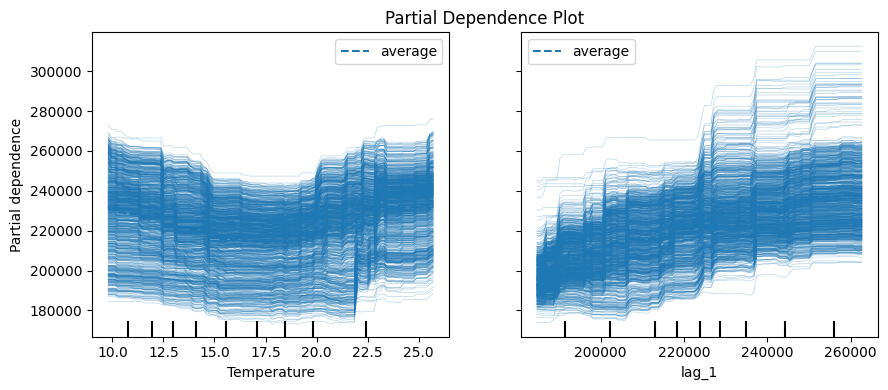

In [43]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

## **Jawaban Pertanyaan**

## 1. Analisa prediksi tentang apa?

Analisis prediksi pada notebook ini berfokus pada prediksi permintaan listrik harian (daily electricity demand) di wilayah Victoria, Australia. Prediksi dilakukan dengan memanfaatkan data historis konsumsi listrik yang telah terjadi sebelumnya serta informasi temperatur harian sebagai variabel pendukung. Tujuan utama dari analisis ini adalah memperkirakan kebutuhan listrik pada hari berikutnya sehingga pola konsumsi energi dapat dipahami dan diantisipasi dengan lebih baik. Dalam dunia nyata, hasil prediksi seperti ini sangat penting bagi perusahaan penyedia listrik karena dapat digunakan untuk perencanaan kapasitas pembangkit, distribusi energi, serta pengelolaan beban listrik agar pasokan tetap stabil dan efisien.


## 2. Bagaimana bentuk data trainingnya (apa saja inputnya dan apa outputnya)?

Sebelum digunakan untuk melatih model, data time series terlebih dahulu diubah ke dalam bentuk supervised learning. Pada proses ini, model tidak langsung menggunakan data mentah, melainkan menggunakan sejumlah data historis sebagai fitur masukan (input).

Input yang digunakan terdiri dari:

* Lag 1 (permintaan listrik satu hari sebelumnya)
* Lag 2 (permintaan listrik dua hari sebelumnya)
* Lag 3 (permintaan listrik tiga hari sebelumnya)
* Lag 4 (permintaan listrik empat hari sebelumnya)
* Lag 5 (permintaan listrik lima hari sebelumnya)
* Lag 6 (permintaan listrik enam hari sebelumnya)
* Lag 7 (permintaan listrik tujuh hari sebelumnya)
* Temperature (rata-rata temperatur harian)

Sedangkan output atau target yang diprediksi adalah:

* Demand (permintaan listrik harian pada hari yang akan diprediksi)

Dengan bentuk data tersebut, model mempelajari hubungan antara pola konsumsi listrik pada beberapa hari sebelumnya serta kondisi temperatur terhadap jumlah kebutuhan listrik pada hari berikutnya.


## 3. Apa itu lag?

Lag merupakan data historis atau data masa lalu yang digunakan sebagai variabel input dalam model prediksi time series. Konsep lag digunakan karena nilai suatu variabel pada masa sekarang sering kali dipengaruhi oleh nilai variabel tersebut pada periode sebelumnya.

Sebagai contoh:

* Lag 1 menunjukkan nilai permintaan listrik satu hari sebelumnya.
* Lag 2 menunjukkan nilai permintaan listrik dua hari sebelumnya.
* Lag 7 menunjukkan nilai permintaan listrik tujuh hari sebelumnya.

Pada notebook ini digunakan sebanyak tujuh lag (lags = 7), sehingga model dapat mempelajari pola konsumsi listrik selama satu minggu terakhir. Penggunaan lag memungkinkan model mengenali pola berulang, tren, maupun fluktuasi yang terjadi pada data historis sehingga hasil prediksi menjadi lebih akurat.

## 4. Jelaskan proses analisis yang dilakukan dari kasus di atas

### Tahap 1: Instalasi dan Import Library

Pada tahap awal dilakukan instalasi dan import library yang dibutuhkan, yaitu Skforecast, LightGBM, Pandas, Matplotlib, dan SHAP. Library tersebut digunakan untuk pengolahan data, pembangunan model prediksi, visualisasi hasil, serta interpretasi model.

### Tahap 2: Pengambilan Dataset

Dataset yang digunakan adalah VIC Electricity yang berisi data permintaan listrik (Demand) dan temperatur (Temperature). Dataset ini digunakan sebagai dasar untuk membangun model prediksi permintaan listrik harian.

### Tahap 3: Agregasi Data Harian

Data yang semula memiliki frekuensi waktu lebih kecil diubah menjadi data harian menggunakan proses resampling. Pada tahap ini nilai Demand dijumlahkan per hari, sedangkan nilai Temperature dihitung rata-ratanya. Tujuannya agar data lebih sesuai untuk analisis forecasting harian.

### Tahap 4: Pembagian Data Training dan Testing

Dataset kemudian dibagi menjadi dua bagian, yaitu data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dilihat sebelumnya.

### Tahap 5: Pembuatan Model Forecasting

Model forecasting dibangun menggunakan ForecasterRecursive dengan algoritma LightGBM sebagai regresor. Model menggunakan 7 lag (lags = 7), sehingga informasi permintaan listrik selama tujuh hari sebelumnya digunakan untuk memprediksi permintaan listrik pada hari berikutnya.

### Tahap 6: Pembentukan Data Training

Data time series diubah menjadi bentuk supervised learning. Variabel input terdiri dari lag_1 hingga lag_7 dan Temperature, sedangkan variabel output adalah Demand. Bentuk data ini memungkinkan algoritma machine learning mempelajari hubungan antara data historis dan target yang akan diprediksi.

### Tahap 7: Pelatihan Model

Model kemudian dilatih menggunakan data training yang telah disiapkan. Pada tahap ini LightGBM mempelajari pola hubungan antara permintaan listrik masa lalu, temperatur, dan permintaan listrik pada hari berikutnya.

### Tahap 8: Analisis Feature Importance

Setelah model selesai dilatih, dilakukan analisis feature importance untuk mengetahui fitur mana yang paling berpengaruh terhadap hasil prediksi. Analisis ini membantu memahami faktor-faktor utama yang digunakan model dalam membuat keputusan.

### Tahap 9: Analisis Explainability Menggunakan SHAP

Metode SHAP digunakan untuk menjelaskan kontribusi masing-masing fitur terhadap hasil prediksi. Analisis dilakukan menggunakan SHAP Bar Plot, SHAP Summary Plot, SHAP Dependence Plot, dan SHAP Force Plot sehingga dapat diketahui bagaimana setiap fitur memengaruhi output model.

### Tahap 10: Prediksi Data Baru

Model yang telah dilatih digunakan untuk memprediksi permintaan listrik pada data testing. Hasil prediksi ini menunjukkan kemampuan model dalam memperkirakan kebutuhan listrik berdasarkan pola historis yang telah dipelajari sebelumnya.

### Tahap 11: Interpretasi Hasil Prediksi

Tahap terakhir adalah menganalisis hasil prediksi dan interpretasi model menggunakan SHAP. Dari tahap ini dapat diketahui alasan model menghasilkan suatu prediksi tertentu, fitur yang paling berpengaruh, serta hubungan antara temperatur dan permintaan listrik harian.


